# Inference e valutazione

Carichiamo il "best model" (epoca 2, val loss 1.95) e generiamo didascalie
sul test set per valutarne la qualita'.

## Cosa fa questo notebook
1. Ricarica il best model + tokenizer + image processor
2. Demo qualitativa: visualizza N immagini test con didascalia generata vs quelle umane
3. Calcola BLEU score sull'intero test set (1091 immagini)
4. Analisi degli errori: didascalie ben/male generate

## Metriche
- **BLEU-1, BLEU-2, BLEU-3, BLEU-4**: precisione di n-gram tra predizione e
  le 5 reference umane. BLEU-4 e' lo standard di riferimento per image captioning.
- Useremo `sacrebleu` per il calcolo (implementazione "ufficiale" e citabile).

## Generazione
- Beam search con `num_beams=4`: esplora 4 ipotesi in parallelo, sceglie la migliore
- `no_repeat_ngram_size=3`: evita ripetizioni di trigrammi (problema comune nei decoder)
- `early_stopping=True`: si ferma quando tutte le beam hanno generato EOS

In [1]:
import torch
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from transformers import (
    VisionEncoderDecoderModel,
    GPT2Tokenizer,
    ViTImageProcessor,
    GenerationConfig,
)
import sacrebleu
from tqdm.auto import tqdm
import json
import random

# Riproducibilita'
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "flickr8k"
IMAGES_DIR = DATA_DIR / "Images"
SPLIT_FILE = DATA_DIR / "captions_with_split.csv"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
BEST_MODEL_DIR = CHECKPOINT_DIR / "best"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)

print(f"Caricamento best model da {BEST_MODEL_DIR}")


Device: cuda
Caricamento best model da c:\dev\image-captioning\checkpoints\best


In [2]:
# Caricamento
INITIAL_MODEL_DIR = CHECKPOINT_DIR / "model_initial"

model = VisionEncoderDecoderModel.from_pretrained(BEST_MODEL_DIR)
tokenizer = GPT2Tokenizer.from_pretrained(INITIAL_MODEL_DIR)        # <-- da qui
image_processor = ViTImageProcessor.from_pretrained(INITIAL_MODEL_DIR)  # <-- da qui
tokenizer.pad_token = tokenizer.eos_token

# Configurazione di generazione (API moderna -> evitiamo i warning del notebook 02/03)
generation_config = GenerationConfig(
    max_length=30,
    num_beams=4,
    early_stopping=True,
    no_repeat_ngram_size=3,
    pad_token_id=tokenizer.pad_token_id,
    bos_token_id=tokenizer.bos_token_id,
    eos_token_id=tokenizer.eos_token_id,
    decoder_start_token_id=tokenizer.bos_token_id,
)
model.generation_config = generation_config

model = model.to(device)
model.eval()  # IMPORTANTE: disabilita dropout, batch norm in mode eval
print(f"Modello su {device}, in eval mode")


def generate_caption(image_path, model, image_processor, tokenizer, device):
    """Genera una singola didascalia per un'immagine."""
    image = Image.open(image_path).convert("RGB")
    pixel_values = image_processor(image, return_tensors="pt").pixel_values.to(device)
    
    # Forziamo la generazione a partire da [BOS, BOS] cosi' saltiamo il falso EOS iniziale.
    # E' un workaround per il fatto che GPT-2 usa lo stesso ID per BOS/EOS/PAD.
    decoder_input_ids = torch.tensor(
        [[tokenizer.bos_token_id, tokenizer.bos_token_id]],
        device=device,
    )
    
    with torch.no_grad():
        output_ids = model.generate(
            pixel_values=pixel_values,
            decoder_input_ids=decoder_input_ids,
            max_length=30,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            bos_token_id=tokenizer.bos_token_id,
        )
    
    caption = tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()
    return caption


# Test su una singola immagine per sanity check
df = pd.read_csv(SPLIT_FILE)
test_df = df[df['split'] == 'test'].copy()
test_images = test_df['image'].unique()
print(f"\nTest set: {len(test_images)} immagini, {len(test_df)} didascalie reference")

# Sanity: genera per la prima immagine test
sample_img = test_images[0]
sample_path = IMAGES_DIR / sample_img
generated = generate_caption(sample_path, model, image_processor, tokenizer, device)
real_captions = test_df[test_df['image'] == sample_img]['caption'].tolist()

print(f"\n=== Sanity check ===")
print(f"Immagine: {sample_img}")
print(f"Generata: {generated!r}")
print(f"Reference (1/5): {real_captions[0]!r}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Modello su cuda, in eval mode

Test set: 1091 immagini, 5455 didascalie reference

=== Sanity check ===
Immagine: 1007320043_627395c3d8.jpg
Generata: 'A young girl wearing a pink shirt and blue jeans is climbing on a rope swing.'
Reference (1/5): 'A child playing on a rope net .'


In [3]:
# === DEBUG: cosa produce davvero generate()? ===
sample_path = IMAGES_DIR / test_images[0]
image = Image.open(sample_path).convert("RGB")
pixel_values = image_processor(image, return_tensors="pt").pixel_values.to(device)

print(f"pixel_values shape: {pixel_values.shape}")
print(f"BOS token id: {tokenizer.bos_token_id}")
print(f"EOS token id: {tokenizer.eos_token_id}")
print(f"PAD token id: {tokenizer.pad_token_id}")
print(f"decoder_start_token_id: {model.config.decoder_start_token_id}")
print()

# Test 1: generate "naked" senza nessun parametro
print("--- Test 1: generate() senza parametri ---")
with torch.no_grad():
    out1 = model.generate(pixel_values=pixel_values)
print(f"Output shape: {out1.shape}")
print(f"Output ids: {out1[0].tolist()}")
print(f"Decoded (no skip): {tokenizer.decode(out1[0], skip_special_tokens=False)!r}")
print(f"Decoded (skip):    {tokenizer.decode(out1[0], skip_special_tokens=True)!r}")
print()

# Test 2: greedy senza early stopping, max_length forzato a 30
print("--- Test 2: greedy, max_length=30, no early stop ---")
with torch.no_grad():
    out2 = model.generate(
        pixel_values=pixel_values,
        max_length=30,
        num_beams=1,  # greedy
        do_sample=False,
        early_stopping=False,
        decoder_start_token_id=tokenizer.bos_token_id,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
print(f"Output shape: {out2.shape}")
print(f"Output ids: {out2[0].tolist()}")
print(f"Decoded (no skip): {tokenizer.decode(out2[0], skip_special_tokens=False)!r}")
print(f"Decoded (skip):    {tokenizer.decode(out2[0], skip_special_tokens=True)!r}")
print()

# Test 3: greedy SENZA fornire eos_token_id (cosi non si ferma)
print("--- Test 3: greedy, eos_token_id=None ---")
with torch.no_grad():
    out3 = model.generate(
        pixel_values=pixel_values,
        max_length=30,
        num_beams=1,
        do_sample=False,
        decoder_start_token_id=tokenizer.bos_token_id,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=None,
    )
print(f"Output shape: {out3.shape}")
print(f"Output ids: {out3[0].tolist()}")
print(f"Decoded (no skip): {tokenizer.decode(out3[0], skip_special_tokens=False)!r}")
print(f"Decoded (skip):    {tokenizer.decode(out3[0], skip_special_tokens=True)!r}")

pixel_values shape: torch.Size([1, 3, 224, 224])
BOS token id: 50256
EOS token id: 50256
PAD token id: 50256
decoder_start_token_id: 50256

--- Test 1: generate() senza parametri ---
Output shape: torch.Size([1, 2])
Output ids: [50256, 50256]
Decoded (no skip): '<|endoftext|><|endoftext|>'
Decoded (skip):    ''

--- Test 2: greedy, max_length=30, no early stop ---
Output shape: torch.Size([1, 2])
Output ids: [50256, 50256]
Decoded (no skip): '<|endoftext|><|endoftext|>'
Decoded (skip):    ''

--- Test 3: greedy, eos_token_id=None ---


c:\dev\image-captioning\.venv\Lib\site-packages\transformers\generation\configuration_utils.py:615: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


Output shape: torch.Size([1, 30])
Output ids: [50256, 50256, 317, 2576, 287, 257, 11398, 10147, 318, 14281, 257, 2266, 290, 7872, 17182, 9628, 764, 220, 50256, 317, 1862, 2576, 287, 11398, 318, 2712, 319, 257, 24817, 764]
Decoded (no skip): '<|endoftext|><|endoftext|> A girl in a pink shirt is climbing a red and yellow rope swing. <|endoftext|> A young girl in pink is playing on a playground.'
Decoded (skip):    ' A girl in a pink shirt is climbing a red and yellow rope swing.  A young girl in pink is playing on a playground.'


Generazione di 8 didascalie di esempio (dal test set, immagini MAI viste in training)...


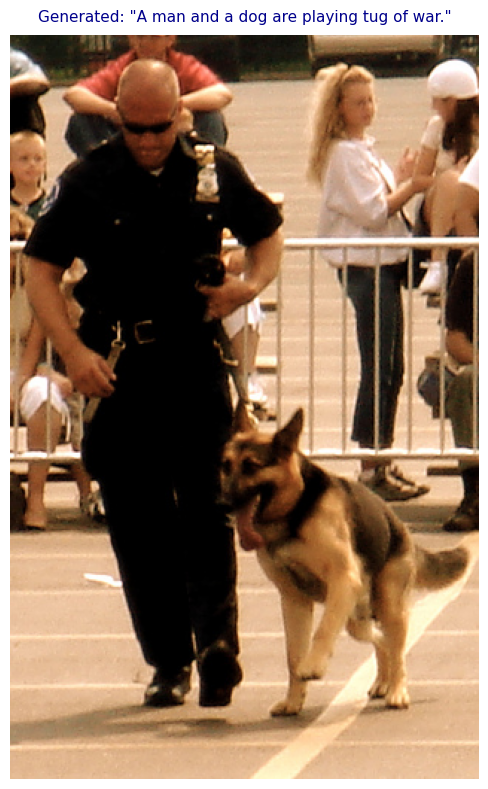

Reference umane:
  1. A bald policeman is walking with a German shepherd dog by a metal crowd control barrier .
  2. An officer and dog are walking in front of a queue of people .
  3. A policeman is next to his German shepherd .
  4. A policeman walks away from a gate with a large brown and black dog .
  5. The policeman walks with his German shepherd .

--------------------------------------------------------------------------------


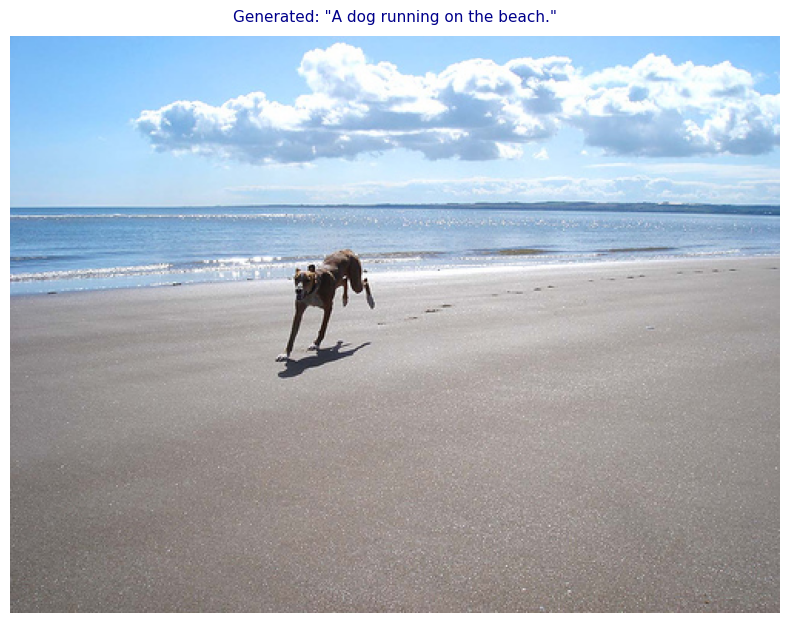

Reference umane:
  1. A dog is running along a beach on a sunny day .
  2. A dog running at the beach in front of the ocean and a bright blue cloudy sky .
  3. A dog runs along the short at a beach .
  4. A lean dog runs along the beach .
  5. Slender dog running in the sand on a sunny day .

--------------------------------------------------------------------------------


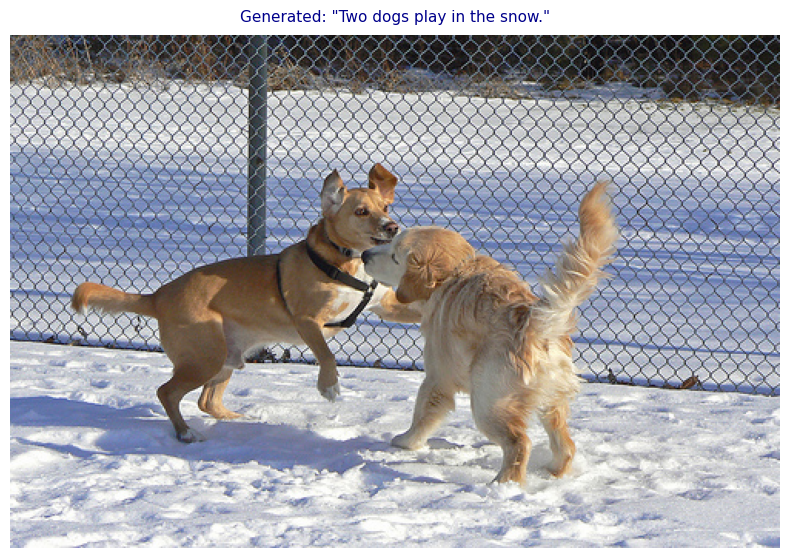

Reference umane:
  1. One dog is jumping up at another dog by a fence on a snowy day .
  2. Two blond dogs sniff one another .
  3. Two dogs in snow .
  4. Two dogs play in the snow
  5. Two tan dogs play in the snow .

--------------------------------------------------------------------------------


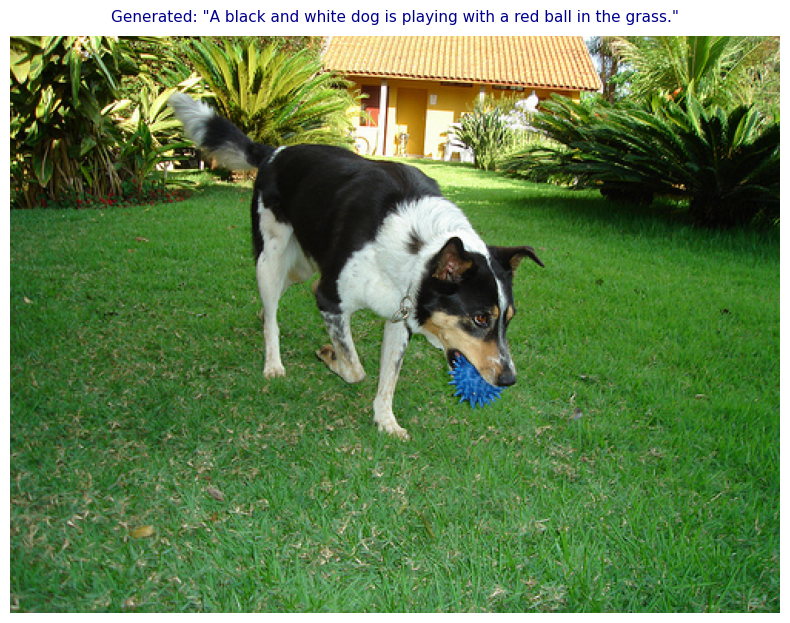

Reference umane:
  1. A black and white dog is carrying a blue ball through the yard of a house in a tropical location .
  2. A black and white dog with a blue dog toy in its mouth walks across a grassy yard .
  3. A dog plays with a blue spiky ball in the grass .
  4. a dog plays with a toy .
  5. Black and white dog has blue ball in mouth .

--------------------------------------------------------------------------------


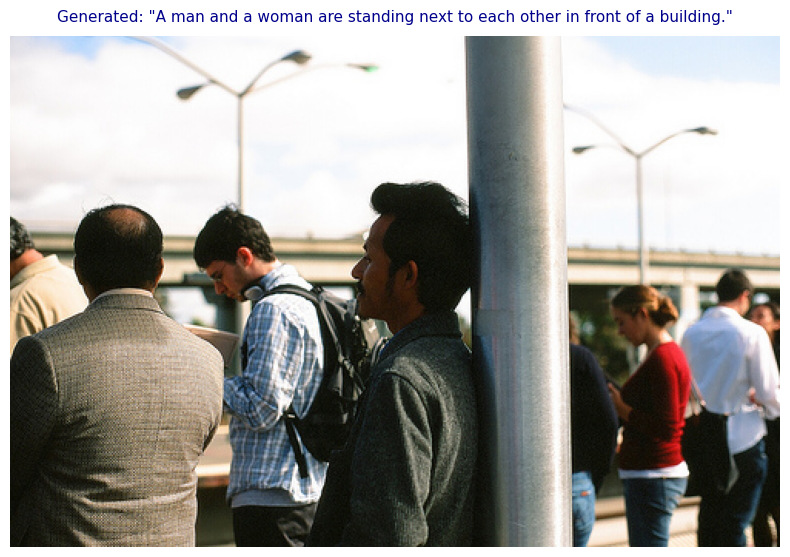

Reference umane:
  1. A dark-haired , grey-suited man is leaning on a silver pole .
  2. A man leaning against a pole surrounded by people
  3. A man leans against a metal pole .
  4. A Middle Eastern man is standing with his back against a lamp post near to other people who are waiting around .
  5. Several people are standing on a sidewalk near a man leaning against a pole .

--------------------------------------------------------------------------------


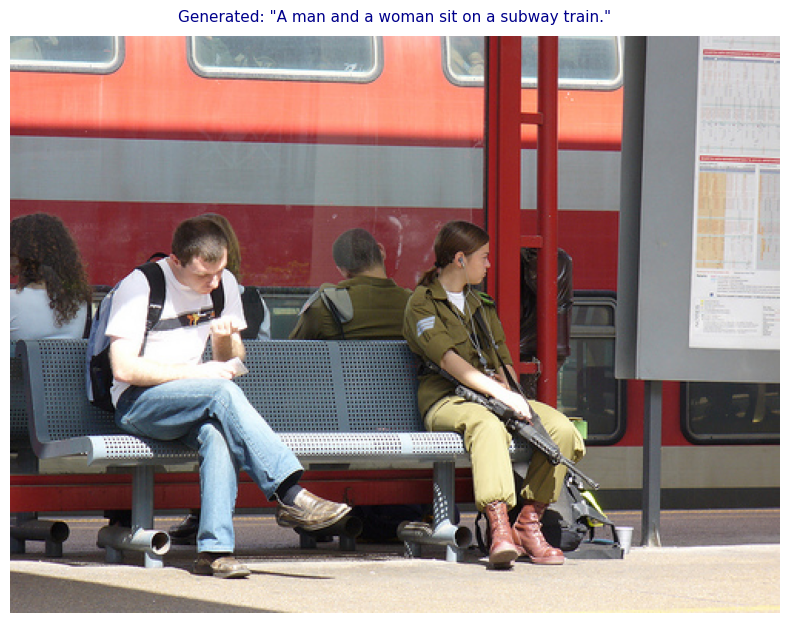

Reference umane:
  1. soldiers 2 and civillians sitting on a bench at a busstop
  2. A man and a woman are waiting for a train , ignoring each other .
  3. A man in blue jeans sits on a bench near a woman in green pants with a red and white bus behind them .
  4. Five people are sitting on benches waiting for the bus .
  5. Two people wait on a bench .

--------------------------------------------------------------------------------


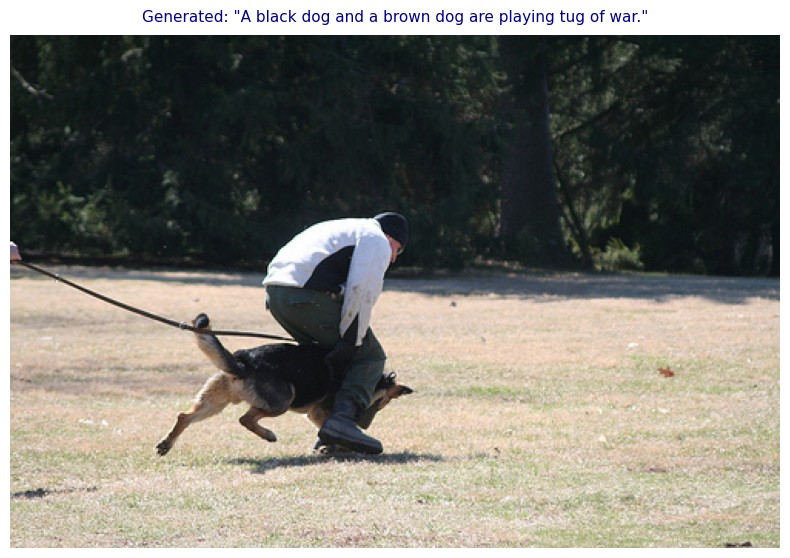

Reference umane:
  1. A man is sitting on a black and brown dog .
  2. A man stands over a brown and black dog in the grass .
  3. a man wearing a black and white shirt jumping on a dog 's back
  4. An attack dog is working with his trainer .
  5. A running dog and a standing man on a dry field of grass .

--------------------------------------------------------------------------------


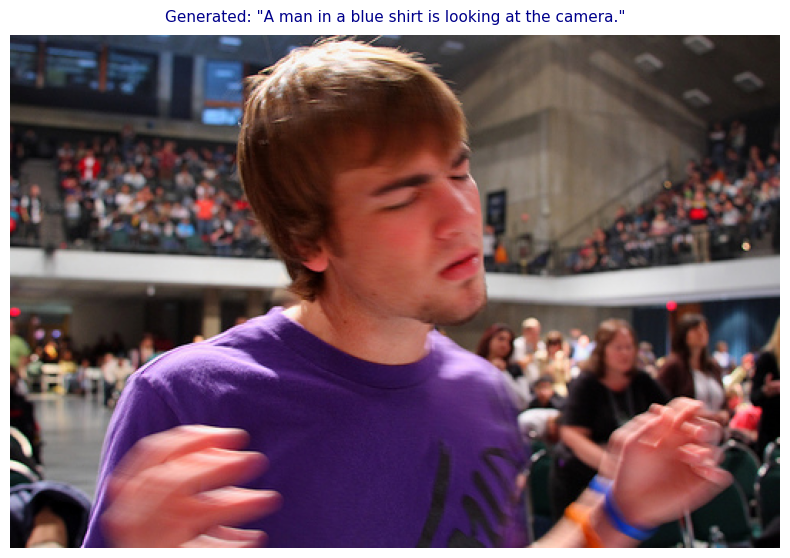

Reference umane:
  1. A boy appears to be dancing to music in a building filled with people .
  2. A man consumed by his surroundings .
  3. a man in a purple shirt is standing in a stadium with his eyes closed .
  4. A man in a purple shirt is standing with his eyes closed .
  5. A young man with a beard at an event .

--------------------------------------------------------------------------------


In [4]:
def show_image_with_predictions(image_filename, generated_caption, real_captions, images_dir):
    """Mostra immagine + caption generata + 5 caption reali."""
    img = Image.open(images_dir / image_filename)
    
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Generated: \"{generated_caption}\"", 
                 fontsize=11, color='darkblue', wrap=True, pad=10)
    plt.tight_layout()
    plt.show()
    
    print("Reference umane:")
    for i, cap in enumerate(real_captions, 1):
        print(f"  {i}. {cap}")
    print()


# Estrai 8 immagini casuali dal test set
sample_test_images = random.sample(list(test_images), 8)

print("Generazione di 8 didascalie di esempio (dal test set, immagini MAI viste in training)...")
print("=" * 80)

for img_name in sample_test_images:
    img_path = IMAGES_DIR / img_name
    generated = generate_caption(img_path, model, image_processor, tokenizer, device)
    real_caps = test_df[test_df['image'] == img_name]['caption'].tolist()
    show_image_with_predictions(img_name, generated, real_caps, IMAGES_DIR)
    print("-" * 80)

## Valutazione quantitativa: BLEU score sul test set

Il BLEU (Bilingual Evaluation Understudy) e' la metrica standard per
image captioning. Misura la sovrapposizione di n-gram tra la didascalia
generata e le 5 reference umane:

- **BLEU-1**: precisione di unigrammi (parole singole)
- **BLEU-2**: 2-grammi (coppie di parole consecutive)
- **BLEU-3**: 3-grammi
- **BLEU-4**: 4-grammi (la metrica "ufficiale" di confronto nei paper)

Range: [0, 100]. Per Flickr8k:
- BLEU-1 atteso: 55-65 (bag-of-words preciso)
- BLEU-4 atteso: 15-25 (sequenze esatte di 4 parole, molto piu' difficile)

Stato dell'arte 2017-2018: BLEU-4 ~25-30. Modelli moderni 2024+: 35-40+.

Questo BLEU e' il **baseline da battere** nelle settimane 1-3 del piano di sviluppo.

In [5]:
import time

print(f"Generazione di {len(test_images)} didascalie sul test set...")
print("(beam search con num_beams=4, ~1 sec per immagine)")
print()

generated_captions = {}   # {image_filename: caption_generata}
real_captions_dict = {}   # {image_filename: [5 reference]}

start = time.time()
for img_name in tqdm(test_images, desc="Generazione"):
    img_path = IMAGES_DIR / img_name
    generated_captions[img_name] = generate_caption(img_path, model, image_processor, tokenizer, device)
    real_captions_dict[img_name] = test_df[test_df['image'] == img_name]['caption'].tolist()

elapsed = time.time() - start
print(f"\nTempo totale: {elapsed/60:.1f} min")
print(f"Throughput: {len(test_images)/elapsed:.2f} immagini/sec")

# Salviamo le didascalie generate per ispezioni successive
output_file = OUTPUTS_DIR / "test_predictions_baseline.json"
output_data = [
    {
        "image": img,
        "generated": generated_captions[img],
        "references": real_captions_dict[img],
    }
    for img in test_images
]
with open(output_file, "w") as f:
    json.dump(output_data, f, indent=2)
print(f"Predizioni salvate in: {output_file}")

# Anteprima dei primi 3 esempi
print("\nAnteprima:")
for img in test_images[:3]:
    print(f"\n  {img}")
    print(f"    GEN: {generated_captions[img]}")
    print(f"    REF: {real_captions_dict[img][0]}")

Generazione di 1091 didascalie sul test set...
(beam search con num_beams=4, ~1 sec per immagine)



Generazione:   0%|          | 0/1091 [00:00<?, ?it/s]


Tempo totale: 5.5 min
Throughput: 3.30 immagini/sec
Predizioni salvate in: c:\dev\image-captioning\outputs\test_predictions_baseline.json

Anteprima:

  1007320043_627395c3d8.jpg
    GEN: A young girl wearing a pink shirt and blue jeans is climbing on a rope swing.
    REF: A child playing on a rope net .

  1026685415_0431cbf574.jpg
    GEN: A black dog is carrying a red ball in its mouth.
    REF: A black dog carries a green toy in his mouth as he walks through the grass .

  1057210460_09c6f4c6c1.jpg
    GEN: A man stands in front of a building while a woman looks on.
    REF: A guy stands by a window taking his overshirt off .


In [6]:
# sacrebleu vuole input "trasposto":
# - hypotheses: lista di N stringhe (una per immagine)
# - references: lista di K liste di N stringhe (K = numero di reference per immagine = 5)
#   references[k][i] = la k-esima reference per la i-esima immagine

hypotheses = [generated_captions[img] for img in test_images]
references_per_image = [real_captions_dict[img] for img in test_images]  # N x 5

# Tutte le immagini hanno 5 reference: trasponiamo in 5 x N
references_transposed = list(zip(*references_per_image))
references_transposed = [list(refs) for refs in references_transposed]

print(f"Hypotheses: {len(hypotheses)} stringhe")
print(f"References: {len(references_transposed)} liste da {len(references_transposed[0])} stringhe ciascuna")
print()

# Calcolo BLEU
bleu = sacrebleu.corpus_bleu(hypotheses, references_transposed)

print("=" * 55)
print("    BLEU score sul test set di Flickr8k")
print(f"    Modello: best (epoca 2, val loss 1.95)")
print("=" * 55)
print(f"  BLEU-1: {bleu.precisions[0]:.2f}")
print(f"  BLEU-2: {bleu.precisions[1]:.2f}")
print(f"  BLEU-3: {bleu.precisions[2]:.2f}")
print(f"  BLEU-4: {bleu.precisions[3]:.2f}")
print(f"  BLEU score (geometric mean delle 4): {bleu.score:.2f}")
print()
print(f"  Brevity penalty: {bleu.bp:.4f}")
print(f"  Lunghezza media generata:  {bleu.sys_len / len(hypotheses):.1f} parole")
print(f"  Lunghezza media reference: {bleu.ref_len / len(hypotheses):.1f} parole")

# Salviamo i risultati
results = {
    "experiment": "scenario_A_baseline",
    "model": "ViT-base + GPT-2 small",
    "dataset": "Flickr8k",
    "best_epoch": 2,
    "best_val_loss": 1.9470,
    "BLEU_1": round(bleu.precisions[0], 2),
    "BLEU_2": round(bleu.precisions[1], 2),
    "BLEU_3": round(bleu.precisions[2], 2),
    "BLEU_4": round(bleu.precisions[3], 2),
    "BLEU_corpus": round(bleu.score, 2),
    "brevity_penalty": round(bleu.bp, 4),
    "avg_generated_length": round(bleu.sys_len / len(hypotheses), 2),
    "avg_reference_length": round(bleu.ref_len / len(hypotheses), 2),
    "n_test_images": len(test_images),
}
with open(OUTPUTS_DIR / "bleu_results_baseline.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"\nRisultati salvati in: {OUTPUTS_DIR / 'bleu_results_baseline.json'}")
print("\nQuesto e' il BASELINE da battere nelle settimane 1-3 del piano.")

Hypotheses: 1091 stringhe
References: 5 liste da 1091 stringhe ciascuna

    BLEU score sul test set di Flickr8k
    Modello: best (epoca 2, val loss 1.95)
  BLEU-1: 65.72
  BLEU-2: 32.27
  BLEU-3: 16.72
  BLEU-4: 8.31
  BLEU score (geometric mean delle 4): 23.30

  Brevity penalty: 1.0000
  Lunghezza media generata:  12.1 parole
  Lunghezza media reference: 11.7 parole

Risultati salvati in: c:\dev\image-captioning\outputs\bleu_results_baseline.json

Questo e' il BASELINE da battere nelle settimane 1-3 del piano.


## Conclusioni del notebook 04 — Baseline Scenario A

### Risultati quantitativi
| Metrica | Valore |
|---------|--------|
| BLEU-1  | 65.72  |
| BLEU-2  | 32.27  |
| BLEU-3  | 16.72  |
| BLEU-4  |  8.31  |
| BLEU corpus | 23.30 |

### Interpretazione
- **BLEU-1 ~66**: il modello identifica correttamente il "vocabolario visivo"
  (soggetti, oggetti, ambientazioni). Le parole giuste compaiono nelle didascalie
  generate.
- **Crollo BLEU-4 ~8**: le sequenze esatte di 4 parole consecutive coincidono
  raramente con le reference umane. Il modello produce descrizioni lunghe e
  dettagliate (12.1 parole medie) mentre le reference sono asciutte (11.7).
  Linguisticamente "creativo" ma sintatticamente diverso dagli annotatori.
- **Errori tipici** (vedi demo qualitativa):
  - Soggetti rari: poliziotti, soldati, uniformi → confusi
  - Colori: confusione di tonalita' (blu↔viola, blu↔rosso)
  - Scene urbane complesse → didascalie generiche

### Conclusioni
Il modello dello Scenario A funziona ma e' chiaramente sotto-addestrato
(2 epoche per overfitting precoce). Le ottimizzazioni dello Scenario B
dovrebbero migliorare significativamente BLEU-4 senza necessariamente
toccare l'architettura.

### Prossimi passi (vedi `PROJECT_PLAN.md`)
- **Settimana 1**: Scenario B su Flickr8k. Atteso BLEU-4 ~18-22.
- **Settimana 2**: Flickr30k. Atteso BLEU-4 ~22-26.
- **Settimana 3**: CLIP encoder. Atteso BLEU-4 ~26-30.